In [1]:
import numpy as np
import math
import random
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
def entropy(num_states):
    if num_states <= 0:
        return 0
    return math.log2(num_states)

def binary_search_with_entropy(target, low=1, high=100):
    steps = 0
    entropies = []
    
    while low <= high:
        steps += 1
        
        # Track entropy before the guess
        num_states = high - low + 1
        entropies.append(entropy(num_states))
        
        mid = (low + high) // 2
        
        if mid == target:
            break
        elif target > mid:
            low = mid + 1
        else:
            high = mid - 1
    
    # Final entropy (should be 0)
    entropies.append(0)
    
    return steps, entropies

def random_guess_with_entropy(target, low=1, high=100):
    steps = 0
    possible = list(range(low, high + 1))
    entropies = []
    
    while possible:
        steps += 1
        
        # Track entropy before guess
        entropies.append(entropy(len(possible)))
        
        guess = random.choice(possible)
        
        if guess == target:
            break
        
        # Eliminate inconsistent values
        if guess < target:
            possible = [x for x in possible if x > guess]
        else:
            possible = [x for x in possible if x < guess]
    
    # Final entropy
    entropies.append(0)
    
    return steps, entropies

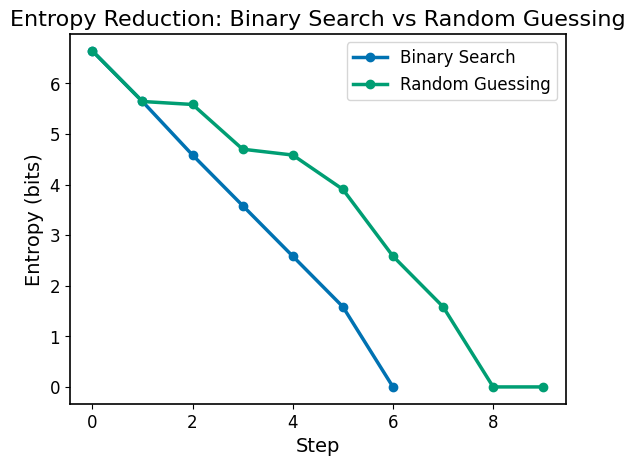

In [3]:
random.seed(0)

target = 73

bs_steps, bs_entropy = binary_search_with_entropy(target)
rg_steps, rg_entropy = random_guess_with_entropy(target)

plt.figure()

plt.plot(bs_entropy, marker='o', label='Binary Search')
plt.plot(rg_entropy, marker='o', label='Random Guessing')

plt.xlabel("Step")
plt.ylabel("Entropy (bits)")
plt.title("Entropy Reduction: Binary Search vs Random Guessing")
plt.legend()

plt.show()

In [4]:
def run_experiments(n_trials=1000, low=1, high=100):
    bs_steps_all = []
    rg_steps_all = []
    
    bs_entropy_curves = []
    rg_entropy_curves = []
    
    max_len = 0
    
    for _ in range(n_trials):
        target = random.randint(low, high)
        
        bs_steps, bs_e = binary_search_with_entropy(target, low, high)
        rg_steps, rg_e = random_guess_with_entropy(target, low, high)
        
        bs_steps_all.append(bs_steps)
        rg_steps_all.append(rg_steps)
        
        bs_entropy_curves.append(bs_e)
        rg_entropy_curves.append(rg_e)
        
        max_len = max(max_len, len(bs_e), len(rg_e))
    
    return {
        "bs_steps": bs_steps_all,
        "rg_steps": rg_steps_all,
        "bs_entropy": bs_entropy_curves,
        "rg_entropy": rg_entropy_curves,
        "max_len": max_len
    }

In [5]:
def average_curves(curves, max_len):
    padded = []
    
    for c in curves:
        padded.append(c + [0] * (max_len - len(c)))
    
    avg = [sum(step) / len(step) for step in zip(*padded)]
    return avg

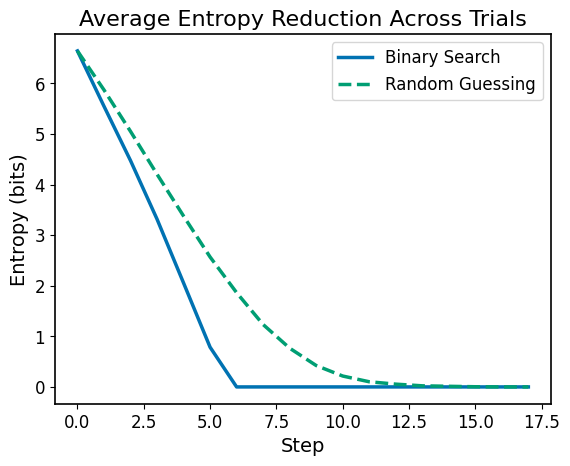

In [6]:
results = run_experiments(1000)

bs_avg = average_curves(results["bs_entropy"], results["max_len"])
rg_avg = average_curves(results["rg_entropy"], results["max_len"])

plt.figure()

plt.plot(bs_avg, label="Binary Search")
plt.plot(rg_avg, linestyle="--", label="Random Guessing")

plt.xlabel("Step")
plt.ylabel("Entropy (bits)")
plt.title("Average Entropy Reduction Across Trials")
plt.legend()

plt.show()

In [7]:
bs_steps = np.array(results["bs_steps"])
rg_steps = np.array(results["rg_steps"])

print("Binary Search:")
print(f"  Mean steps: {bs_steps.mean():.2f}")
print(f"  Std:        {bs_steps.std():.2f}")

print("\nRandom Guessing:")
print(f"  Mean steps: {rg_steps.mean():.2f}")
print(f"  Std:        {rg_steps.std():.2f}")

Binary Search:
  Mean steps: 5.79
  Std:        1.31

Random Guessing:
  Mean steps: 7.55
  Std:        2.78


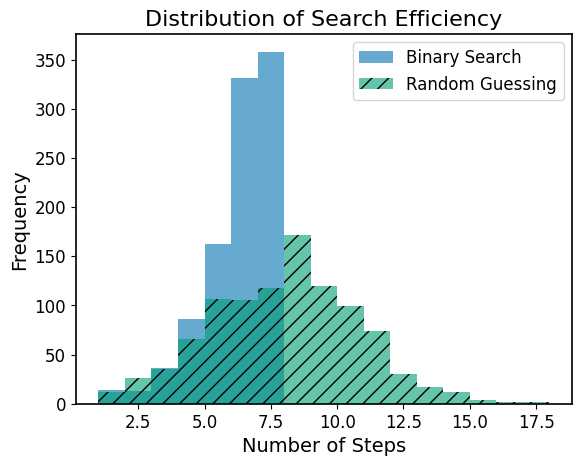

In [8]:
plt.hist(bs_steps, bins=range(1, max(bs_steps)+2), alpha=0.6, label="Binary Search")
plt.hist(rg_steps, bins=range(1, max(rg_steps)+2), alpha=0.6, hatch="//", label="Random Guessing")

plt.xlabel("Number of Steps")
plt.ylabel("Frequency")
plt.title("Distribution of Search Efficiency")
plt.legend()

plt.show()

In [10]:
efficiency = rg_steps / bs_steps
print(f"Average efficiency gap: {efficiency.mean():.2f}x slower")

Average efficiency gap: 1.47x slower
